# 04 Supervised Regression – Online Retail

In diesem Notebook wird das bisherige Projekt um **Supervised Regression** erweitert.

Ziel: Wir möchten den **Kundenumsatz (`total_revenue`)** auf Basis von Kundenmerkmalen vorhersagen.  
Damit passt dieses Notebook logisch zu den vorherigen Schritten:

1. Datenbereinigung  
2. Unsupervised Learning: Kundensegmentierung  
3. Supervised Classification: High-Value-Customer  
4. Supervised Regression: Kundenumsatz vorhersagen


## Schritt 1: Bibliotheken importieren

Zuerst laden wir die benötigten Bibliotheken für Datenverarbeitung, Visualisierung und Machine Learning.

In [1]:
# Datenverarbeitung
import pandas as pd
import numpy as np

# Visualisierung
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

# Bewertung der Regressionsmodelle
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Schritt 2: Bereinigten Datensatz laden

Wir verwenden den bereits bereinigten Datensatz aus dem ersten Notebook.  
Der Dateipfad bleibt gleich und es werden keine zusätzlichen Pfadprüfungen eingebaut.

In [2]:
# Bereinigten Online-Retail-Datensatz laden
# parse_dates sorgt dafür, dass InvoiceDate direkt als Datum erkannt wird.

df = pd.read_csv(
    "../data/online_retail_data_cleaned.csv",
    parse_dates=["InvoiceDate"]
)

# Erste fünf Zeilen anzeigen
df.head()

/tmp/ipykernel_54029/615415426.py:4: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth,IsCancellation
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01,False
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,False


## Schritt 3: Kundendaten für Regression erstellen

Da wir den Umsatz pro Kunde vorhersagen möchten, wird der Transaktionsdatensatz auf Kundenebene aggregiert.

Aus vielen einzelnen Bestellpositionen wird also eine Tabelle mit **einer Zeile pro Kunde**.

In [3]:
# Kundendaten erstellen
# Jede CustomerID wird zu einer Zeile zusammengefasst.

customer_data = df.groupby("CustomerID").agg(
    total_revenue=("TotalPrice", "sum"),
    number_of_orders=("InvoiceNo", "nunique"),
    total_quantity=("Quantity", "sum"),
    unique_products=("StockCode", "nunique"),
    avg_unit_price=("UnitPrice", "mean"),
    first_order=("InvoiceDate", "min"),
    last_order=("InvoiceDate", "max")
).reset_index()

# Zeitraum zwischen erster und letzter Bestellung berechnen
customer_data["customer_lifetime_days"] = (
    customer_data["last_order"] - customer_data["first_order"]
).dt.days

# Datums-Spalten werden danach nicht mehr als Modell-Features verwendet.
customer_data = customer_data.drop(columns=["first_order", "last_order"])

customer_data.head()

,CustomerID,total_revenue,number_of_orders,total_quantity,unique_products,avg_unit_price,customer_lifetime_days
0,12346.0,77183.60,1,74215.0,1,1.040000,0
1,12347.0,4310.00,7,2458.0,103,2.644011,365
2,12348.0,1797.24,4,2341.0,22,5.764839,282
3,12349.0,1757.55,1,631.0,73,8.289041,0
4,12350.0,334.40,1,197.0,17,3.841176,0


## Schritt 4: Zielvariable und Features definieren

Die Zielvariable ist:

- `total_revenue`: gesamter Umsatz eines Kunden

Als Eingabemerkmale verwenden wir kundenbezogene Verhaltensmerkmale:

- Anzahl der Bestellungen
- Gekaufte Gesamtmenge
- Anzahl unterschiedlicher Produkte
- Durchschnittlicher Stückpreis
- Zeitraum zwischen erster und letzter Bestellung

Wichtig: `total_revenue` selbst wird **nicht** als Feature verwendet, weil das ein Datenleck wäre.

In [4]:
# Features für die Umsatzvorhersage
features = [
    "number_of_orders",
    "total_quantity",
    "unique_products",
    "avg_unit_price",
    "customer_lifetime_days"
]

X = customer_data[features]
y = customer_data["total_revenue"]

print("Feature-Matrix:", X.shape)
print("Zielvariable:", y.shape)

Feature-Matrix: (4338, 5)
Zielvariable: (4338,)


## Schritt 5: Daten explorieren

Vor dem Modelltraining schauen wir uns kurz an, wie die Zielvariable verteilt ist.  
Bei Retail-Daten ist der Umsatz oft stark schief verteilt: viele Kunden haben niedrige Umsätze und wenige Kunden sehr hohe Umsätze.

In [5]:
# Statistische Übersicht der Kundendaten
customer_data[["total_revenue"] + features].describe()

,total_revenue,number_of_orders,total_quantity,unique_products,avg_unit_price,customer_lifetime_days
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,2054.266460,4.272476,1191.289073,61.482250,4.467773,130.448594
std,8989.230441,7.698551,5046.081546,85.333637,34.211451,132.039554
min,3.750000,1.000000,1.000000,1.000000,0.122500,0.000000
25%,307.415000,1.000000,160.000000,16.000000,2.203728,0.000000
50%,674.485000,2.000000,379.000000,35.000000,2.917611,92.500000
75%,1661.740000,5.000000,992.750000,77.000000,3.829784,251.750000
max,280206.020000,209.000000,196915.000000,1786.000000,2033.100000,373.000000


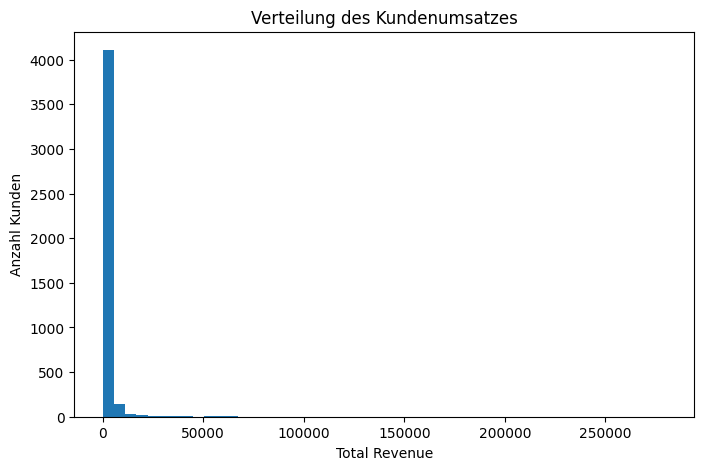

In [6]:
# Verteilung des Kundenumsatzes
plt.figure(figsize=(8, 5))
plt.hist(customer_data["total_revenue"], bins=50)
plt.title("Verteilung des Kundenumsatzes")
plt.xlabel("Total Revenue")
plt.ylabel("Anzahl Kunden")
plt.show()

## Schritt 6: Log-Transformation der Zielvariable

Da der Umsatz stark schief verteilt sein kann, wird für das Modelltraining eine Log-Transformation verwendet.

Dadurch werden extreme Ausreißer abgeschwächt und die Modelle können stabiler lernen.

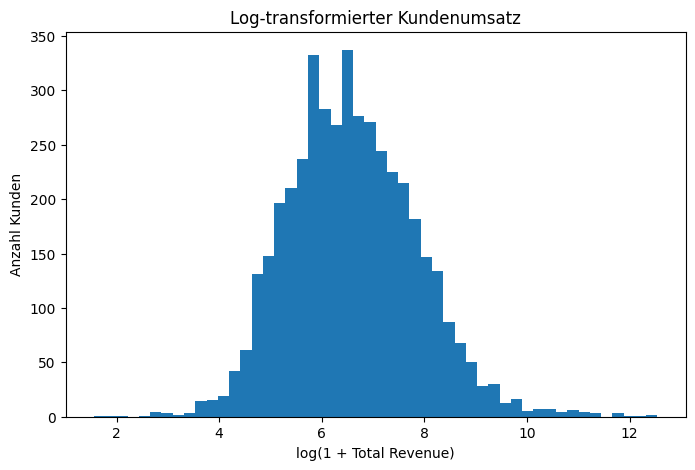

In [7]:
# Log-Transformation der Zielvariable
# np.log1p(x) berechnet log(1 + x) und funktioniert auch bei Werten nahe 0.

y_log = np.log1p(y)

plt.figure(figsize=(8, 5))
plt.hist(y_log, bins=50)
plt.title("Log-transformierter Kundenumsatz")
plt.xlabel("log(1 + Total Revenue)")
plt.ylabel("Anzahl Kunden")
plt.show()

## Schritt 7: Trainings- und Testdaten erstellen

Die Daten werden in Trainings- und Testdaten aufgeteilt.  
Das Modell lernt auf den Trainingsdaten und wird anschließend auf ungesehenen Testdaten bewertet.

In [8]:
# Aufteilung in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

print("Trainingsdaten:", X_train.shape)
print("Testdaten:", X_test.shape)

Trainingsdaten: (3470, 5)
Testdaten: (868, 5)


## Schritt 8: Regressionsmodelle trainieren

Wir vergleichen drei Modelle:

1. Lineare Regression  
2. Decision Tree Regression  
3. Polynomial Regression

Die Features werden vorher skaliert, damit alle Merkmale vergleichbar sind.

In [9]:
# Modell 1: Lineare Regression
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

In [10]:
# Modell 2: Decision Tree Regression
tree_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)
tree_predictions = tree_model.predict(X_test)

In [11]:
# Modell 3: Polynomial Regression
poly_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

poly_model.fit(X_train, y_train)
poly_predictions = poly_model.predict(X_test)

## Schritt 9: Modelle bewerten

Die Modelle werden mit drei Kennzahlen bewertet:

- **MAE**: durchschnittlicher absoluter Fehler  
- **RMSE**: stärker gewichteter Fehler bei großen Abweichungen  
- **R²**: erklärte Varianz des Modells

Da das Modell auf dem log-transformierten Umsatz trainiert wurde, werden die Vorhersagen für MAE und RMSE wieder zurücktransformiert.

In [12]:
# Funktion zur Bewertung der Modelle
def evaluate_model(model_name, y_test_log, predictions_log):
    y_test_original = np.expm1(y_test_log)
    predictions_original = np.expm1(predictions_log)

    mae = mean_absolute_error(y_test_original, predictions_original)
    rmse = np.sqrt(mean_squared_error(y_test_original, predictions_original))
    r2 = r2_score(y_test_log, predictions_log)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2_log_target": r2
    }

results = [
    evaluate_model("Linear Regression", y_test, linear_predictions),
    evaluate_model("Decision Tree Regression", y_test, tree_predictions),
    evaluate_model("Polynomial Regression", y_test, poly_predictions)
]

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2_log_target
0,Linear Regression,3.701479e+03,5.406310e+04,0.620451
1,Decision Tree Regression,7.177926e+02,4.084879e+03,0.896901
2,Polynomial Regression,7.750590e+07,2.283357e+09,0.599354


## Schritt 10: Ergebnisse visualisieren

Zur besseren Vergleichbarkeit werden die Fehlerwerte der Modelle als Balkendiagramm dargestellt.

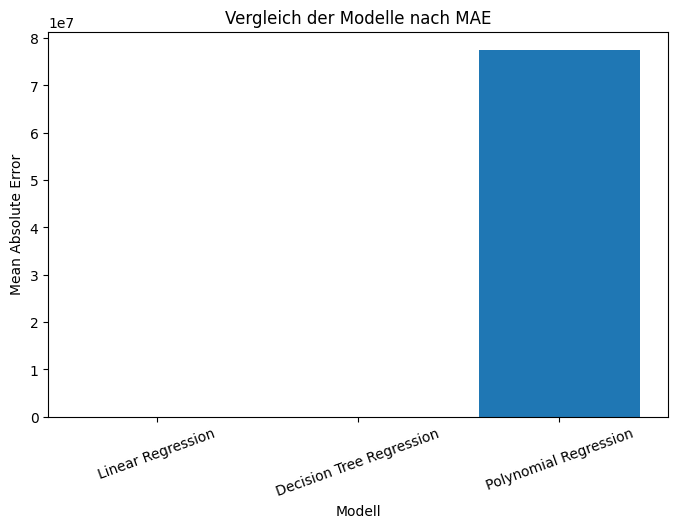

In [13]:
# MAE der Modelle vergleichen
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Vergleich der Modelle nach MAE")
plt.xlabel("Modell")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=20)
plt.show()

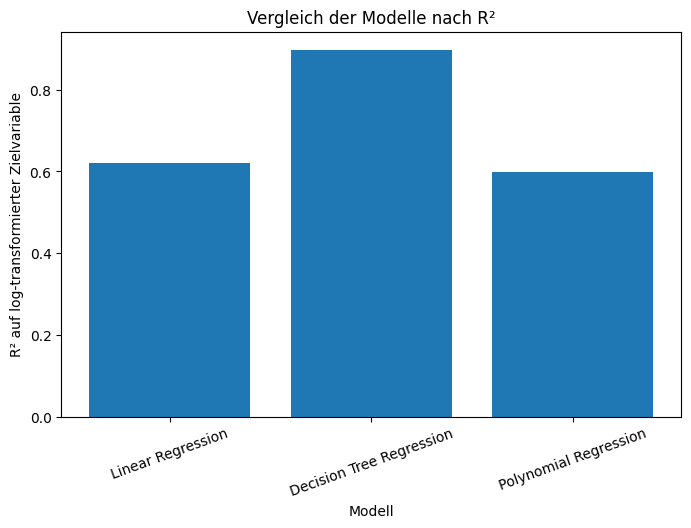

In [14]:
# R² der Modelle vergleichen
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["R2_log_target"])
plt.title("Vergleich der Modelle nach R²")
plt.xlabel("Modell")
plt.ylabel("R² auf log-transformierter Zielvariable")
plt.xticks(rotation=20)
plt.show()

## Schritt 11: Tatsächliche und vorhergesagte Umsätze vergleichen

Zum Schluss wird geprüft, wie nah die Vorhersagen am tatsächlichen Umsatz liegen.

In [15]:
# Bestes Modell anhand des niedrigsten MAE auswählen
best_model_name = results_df.sort_values("MAE").iloc[0]["Model"]

print("Bestes Modell nach MAE:", best_model_name)

Bestes Modell nach MAE: Decision Tree Regression


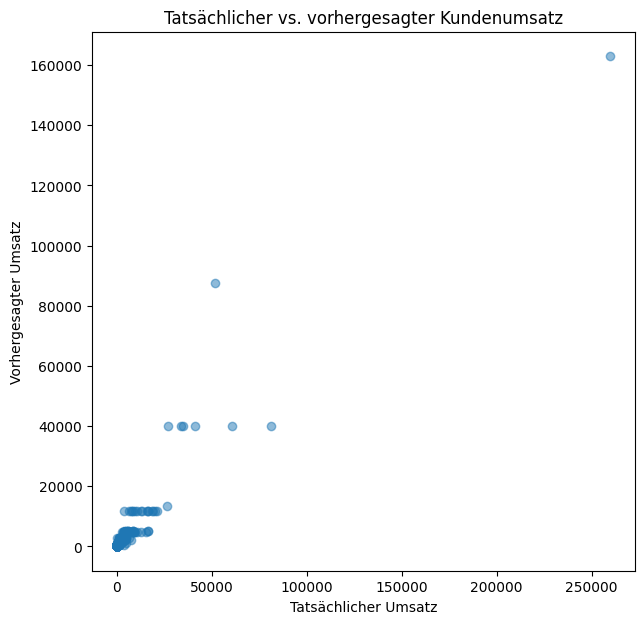

In [16]:
# Für die Visualisierung verwenden wir hier die Vorhersagen des Decision Trees.
# Falls ein anderes Modell besser ist, kann hier die entsprechende Vorhersage eingesetzt werden.

y_test_original = np.expm1(y_test)
predictions_original = np.expm1(tree_predictions)

plt.figure(figsize=(7, 7))
plt.scatter(y_test_original, predictions_original, alpha=0.5)
plt.title("Tatsächlicher vs. vorhergesagter Kundenumsatz")
plt.xlabel("Tatsächlicher Umsatz")
plt.ylabel("Vorhergesagter Umsatz")
plt.show()

## Schritt 12: Ergebnisse exportieren

Die wichtigsten Kundendaten und die Zielvariable werden gespeichert.  
Damit können die Ergebnisse später weiterverwendet oder dokumentiert werden.

In [17]:
# Kundendaten mit Zielvariable exportieren
customer_data.to_csv(
    "../data/online_retail_customer_regression_data.csv",
    index=False
)

customer_data.head()

,CustomerID,total_revenue,number_of_orders,total_quantity,unique_products,avg_unit_price,customer_lifetime_days
0,12346.0,77183.60,1,74215.0,1,1.040000,0
1,12347.0,4310.00,7,2458.0,103,2.644011,365
2,12348.0,1797.24,4,2341.0,22,5.764839,282
3,12349.0,1757.55,1,631.0,73,8.289041,0
4,12350.0,334.40,1,197.0,17,3.841176,0


## Fazit

In diesem Notebook wurde ein Regressionsproblem für den Online-Retail-Datensatz erstellt.

Ziel war es, den **Kundenumsatz** vorherzusagen.  
Dazu wurden zunächst Kundendaten aus den Transaktionen gebildet und anschließend mehrere Regressionsmodelle verglichen.

Dieses Notebook ergänzt die vorherigen Analysen, weil nicht nur Kundengruppen oder Klassen betrachtet werden, sondern ein konkreter numerischer Wert vorhergesagt wird.
